In [91]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
import warnings

warnings.filterwarnings("error", category=RuntimeWarning)

from numba import njit
from Rewrite_Func import relative_error, nash_sutcliffe_efficiency
from SCEUA import sceua

In [104]:
params_json = json.load(open("../conf/parameters.json"))
all_data    = pd.read_csv("../data/L0123001.txt", sep="\t", parse_dates=["Time"], index_col="Time")
data        = np.float64(all_data[['P', 'T', 'E']].values)
params_list = [
    'KC', 'UM', 'LM', 'C',  # 蒸发参数
    'WM', 'B', 'IM',        # 产流参数
    'SM', 'EX', 'KG', 'KI', # 分水源参数
    'CS', 'CI', 'CG',       # 汇流参数（坡面汇流，线性水库）
    'CR'                    # 汇流参数（河网汇流，线性水库）
    ]
params       = np.array([params_json[key]["default"] for key in params_list], dtype=np.float64)
lower_bounds = np.array([params_json[key]["lower_bound"] for key in params_list], dtype=np.float64)
upper_bounds = np.array([params_json[key]["upper_bound"] for key in params_list], dtype=np.float64)
bounds       = np.array([lower_bounds, upper_bounds])

In [ ]:
@njit
def xinanjiang(data:       np.ndarray,
               params:     np.ndarray,
               init_state = np.array([10.0, 40.0, 50.0, 0.0, 0.1, 0.0, 0.0, 0.0, 0.0])) -> np.ndarray:
    """
    Xinanjiang model implementation.
    ------------
    Parameters:

    data: (n, 3) array, where n is the number of time steps, and the columns represent precipitation (P), temperature (T), and potential evapotranspiration (E).

    params: (15,) array, containing the model parameters in the following order:

        Parameters for evapotranspiration:

        KC: Crop coefficient for evapotranspiration. [0.5, 1.0]
        UM: Maximum soil moisture in the upper layer. [10, 50]
        LM: Maximum soil moisture in the lower layer. [40, 90]
        C:  Coefficient for calculating deep soil evaporation. [0.1, 0.2]

        Parameters for runoff generation:

        WM: Maximum soil moisture in the entire soil profile. [80, 200]
        B:  Tension water storage capacity curve equation. [0.1, 0.4]
        IM: The proportion of impermeable area to the total area of the entire basin. [0.005, 0.05]

        Parameters for water partitioning:

        SM: Maximum soil moisture in the free water storage. [5, 50]
        EX: Surface free water storage capacity factor. [1.0, 2.0]
        KG: Coefficient for calculating the partitioning of runoff into subsurface runoff. [0.1, 0.5]
        KI: Coefficient for calculating the partitioning of runoff into Interflow runoff. [0.1, 0.5]

        Parameters for flow routing (slope runoff, linear reservoir):

        CS: Coefficient for calculating the surface runoff. [0.1, 0.4]
        CI: Coefficient for calculating the Interflow runoff. [0.1, 0.999]
        CG: Coefficient for calculating the groundwater runoff. [0.05, 1.0]

        Parameters for flow routing (river network runoff, linear reservoir):

        CR: Coefficient for calculating the river network runoff. [0.05, 0.999]

    init_state: (3,) array, containing the initial soil moisture in the upper layer (WU), lower layer (WL), and deep layer (WD) at the beginning of the time step.
    """
    # 获取参数
    KC, UM, LM, C, WM, B, IM, SM, EX, KG, KI, CS, CI, CG, CR = params
    # 深层土壤蓄水容量
    DM = WM - UM - LM
    # 流域单点最大土壤含水量
    WMM = (1 + B) * WM
    # 流域单点最大自由水含水量
    SMM = (1 + EX) * SM

    # 降水、气温、潜在蒸散发数据
    P = data[:, 0].astype(np.float64)
    T = data[:, 1].astype(np.float64)
    E = data[:, 2].astype(np.float64)
    # 时间步初始三层土壤含水量
    WU0, WL0, WD0 = init_state[:3].astype(np.float64)
    # 时间步开始时的总土壤含水量
    W0 = WU0 + WL0 + WD0

    # 时间步数
    ntimes = data.shape[0]

    # 结果数组
    WU = np.full(ntimes, np.nan, dtype=np.float64)
    WL = np.full(ntimes, np.nan, dtype=np.float64)
    WD = np.full(ntimes, np.nan, dtype=np.float64)
    W  = np.full(ntimes, np.nan, dtype=np.float64)
    EU = np.full(ntimes, np.nan, dtype=np.float64)
    EL = np.full(ntimes, np.nan, dtype=np.float64)
    ED = np.full(ntimes, np.nan, dtype=np.float64)
    ET = np.full(ntimes, np.nan, dtype=np.float64)
    A  = np.full(ntimes, np.nan, dtype=np.float64)
    FR = np.full(ntimes, np.nan, dtype=np.float64)
    S  = np.full(ntimes, np.nan, dtype=np.float64)
    RS = np.full(ntimes, np.nan, dtype=np.float64)
    RI = np.full(ntimes, np.nan, dtype=np.float64)
    RG = np.full(ntimes, np.nan, dtype=np.float64)
    R  = np.full(ntimes, np.nan, dtype=np.float64)

    WU[0], WL[0], WD[0], W[0] = WU0, WL0, WD0, W0
    FR[0] = init_state[3]
    S[0]  = init_state[4]
    RS[0], RG[0], RI[0], R[0] = init_state[5:9]

    for i in range(ntimes):
        # 当前时间步的降水、气温、潜在蒸散发
        # 透水面积部分降水
        p = P[i] * (1.0 - IM)
        e = E[i]

        # 时间步初的土壤含水量
        wu = WU[i-1] if i > 0 else WU0
        wl = WL[i-1] if i > 0 else WL0
        wd = WD[i-1] if i > 0 else WD0
        w  = wu + wl + wd

        a = WMM * (1.0 - np.power(1 - w / WMM, 1.0 / (1.0 + B)))

        # 时间步初始产流面积
        fr0 = FR[i-1] if i > 0 else FR[0]
        s0  = S[i-1]  if i > 0 else S[0]

        # 时间步初始径流量
        rs0 = RS[i-1] if i > 0 else RS[0]
        ri0 = RI[i-1] if i > 0 else RI[0]
        rg0 = RG[i-1] if i > 0 else RG[0]
        r0  = R[i-1]  if i > 0 else R[0]

        ## 蒸散发计算-三层蒸散发模型
        # 流域蒸散发能力
        ep = KC * e

        if p + wu >= ep:
            # 上层土壤足够供给蒸发
            eu = ep
            el = 0.0
            ed = 0.0
            wu1 = wu + p - eu
            wl1 = wl
            wd1 = wd
        else:
            # 上层土壤不够供给蒸发，需要下层和深层支持
            eu  = p + wu
            wu1 = 0.0
            temp_diff = ep - eu
            if wl >= C * LM:
                el = (ep - eu) * wl / LM
                ed = 0.0
            else:
                if wl >= C * (ep - eu):
                    el = C * (ep - eu)
                    ed = 0.0
                else:
                    el = wl
                    if wd >= C * (ep - eu) - el:
                        ed = C * (ep - eu) - el
                    else:
                        ed = wd
            wl1 = wl - el
            wd1 = wd - ed
        # 总蒸散发
        et = eu + el + ed
        # 剩余降水 / 净雨
        pe = p - et
        # 总土壤含水量
        w1 = wu1 + wl1 + wd1

        ## 产流计算
        # 蓄水容量曲线纵坐标
        a = WMM * (1.0 - np.power(1 - w1 / WMM, 1.0 / (1.0 + B)))
        if pe > 0.0:
            if a + pe <= WMM:
                r = pe + w1 - WM + WM * np.power(1.0 - (a + pe) / WMM, 1.0 + B)
            else:
                r = pe + w1 - WM
        else:
            r = 0.0

        ## 后一时刻土壤含水量计算
        if wu + p - eu - r <= UM:
            wu1 = wu + p - eu - r
            wl1 = wl - el
            wd1 = wd - ed
        else:
            wu1 = UM
            if wl - el + wu + p - eu - r - UM <= LM:
                wl1 = wl - el + wu + p - eu - r - UM
                wd1 = wd - ed
            else:
                wl1 = LM
                if wd - ed + wl - el + wu + p - eu - r - UM - LM <= DM:
                    wd1 = wd - ed + wl - el + wu + p - eu - r - UM - LM
                else:
                    wd1 = DM
        w1 = max(wu1 + wl1 + wd1, WM)
        # 三层土壤含水量更新后总超出水量
        excess_water = max(0.0, wd - ed + wl - el + wu + p - eu - r - UM - LM - DM)
        if w1 >= WM:
            a1 = WMM
        else:
            a1 = WMM * (1.0 - np.power(1.0 - w1 / WMM, 1.0 / (1.0 + B)))

        ## 分水源
        s0 = s0 + excess_water
        if pe <= 1e-4:
            rs = 0.0
            ri = s0 * KG * fr0
            rg = s0 * KI * fr0
            s1 = (1.0 - KI - KG) * s0
        else:
            rs = 0.0
            ri = 0.0
            rg = 0.0
            fr1 = max(r / pe, 1e-4)
            s1 = s0 * fr0 / fr1
            SS = s1
            Qall = r / fr1
            nd = int(Qall / 5.0) + 1.0
            Qdiv = Qall / nd

            # 基于径流深分段计算时的参数转换
            Kd_coee = (1.0 - np.power(1.0 - KI - KG, 1.0 / nd)) / (KI + KG)
            KId = Kd_coee * KI
            KGd = Kd_coee * KG

            # 分段进行三种径流深计算，并对S进行更新
            for j in range(int(nd)):
                AU = SMM * (1.0 - np.power(1.0 - s1 / SM, 1.0 / (1.0 + EX)))
                if AU + Qdiv < SMM:
                    rs += (Qdiv - SM + s1 + SM * np.power(1.0 - (Qdiv + AU) / SMM, 1.0 + EX)) * fr1
                else:
                    rs += (Qdiv - SM + s1) * fr1
                s1 += j * Qdiv - rs / fr1
                rg += s1 * KGd * fr1
                ri += s1 * KId * fr1
                s1 = j * Qdiv + SS - (rs + ri + rg) / fr1

        rs = rs + IM * p

        ## 汇流计算
        rs1 = rs0 * CS + rs * (1.0 - CS)
        ri1 = ri0 * CI + ri * (1.0 - CI)
        rg1 = rg0 * CG + rg * (1.0 - CG)
        r_t = rs1 + ri1 + rg1

        r1 = r0 * CR + r_t * (1.0 - CR)

        # 存储结果
        WU[i], WL[i], WD[i], W[i] = wu1, wl1, wd1, w1
        EU[i], EL[i], ED[i], ET[i] = eu, el, ed, et
        A[i], FR[i], S[i] = a1, fr1, s1
        RS[i], RI[i], RG[i], R[i] = rs1, ri1, rg1, r1

    return R

@njit
def cost_function(x, param, observation, fn_hm):
    simulation = fn_hm(x, param)
    NSE = nash_sutcliffe_efficiency(observation, simulation)
    RE  = relative_error(observation, simulation)
    CF = 1 - NSE + 2 * np.abs(RE)
    return CF

NSE: 0.10049932562494657
Relative Error: -0.561020581304592


Text(0, 0.5, 'Runoff (mm)')

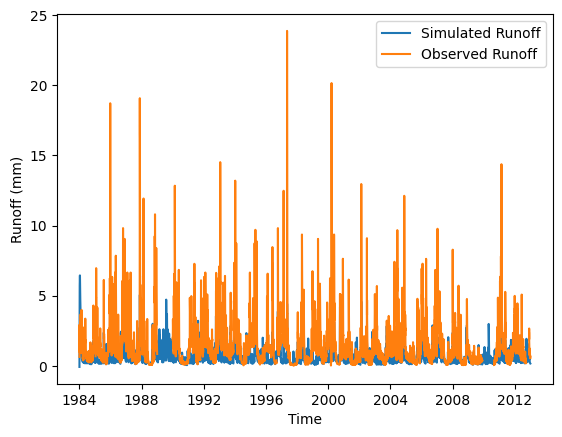

In [108]:
result = xinanjiang(data, params, init_state=np.array([10.0, 40.0, 50.0, 0.0, 0.1, 0.0, 0.0, 0.0, 0.0]))
result_series = pd.Series(result, index=all_data.index)
plt.plot(result_series, label="Simulated Runoff")
plt.plot(all_data['Qmm'], label="Observed Runoff")
print("NSE:", nash_sutcliffe_efficiency(all_data['Qmm'].values, result))
print("Relative Error:", relative_error(all_data['Qmm'].values, result))
plt.legend()
plt.xlabel("Time")
plt.ylabel("Runoff (mm)")

Calibrated NSE: 0.22722383558360026
Calibrated Relative Error: -0.3653510355643999


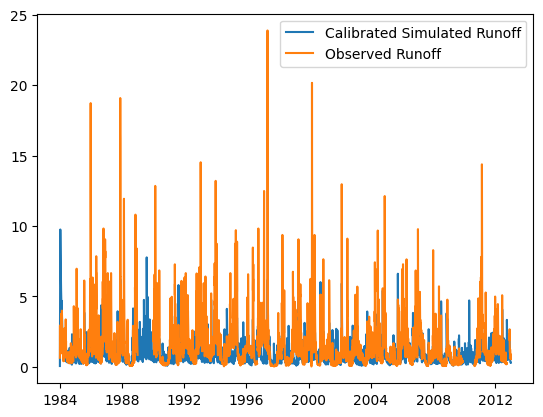

In [112]:
# SCEUA算法参数
max_iter  = 50
n_complex = 10
n_params  = len(params)
fn_hm     = xinanjiang
x_cali = data
y_cali = all_data['Qmm'].values
bestx, calibration_result = sceua(bounds, max_iter, n_complex, n_params, x_cali, y_cali, fn_hm, cost_function)

result = xinanjiang(data, bestx, init_state=np.array([10.0, 40.0, 50.0, 0.0, 0.1, 0.0, 0.0, 0.0, 0.0]))
result_series = pd.Series(result, index=all_data.index)
plt.plot(result_series, label="Calibrated Simulated Runoff")
plt.plot(all_data['Qmm'], label="Observed Runoff")
print("Calibrated NSE:", nash_sutcliffe_efficiency(all_data['Qmm'].values, result))
print("Calibrated Relative Error:", relative_error(all_data['Qmm'].values, result))
plt.legend()

In [117]:
from typing import Tuple
from utils import UH1_D, UH2_D

@njit
def _MOD_GR4J(
        St:     np.ndarray,
        StUH1:  np.ndarray,
        StUH2:  np.ndarray,
        OrdUH1: np.ndarray,
        OrdUH2: np.ndarray,
        Param:  np.ndarray,
        P1:     float,
        E:      float,
        NH:     float,
        NMISC:  float
) -> Tuple[float, np.ndarray]:
    """
    使用GR4J模型在单个时间步（天）上计算流量
    
    Parameters:
    -----------
    st : np.ndarray
        时间步开始时库容的模型状态 [mm]
    StUH1 : np.ndarray
        时间步开始时单位线UH1的模型状态 [mm]
    StUH2 : np.ndarray
        时间步开始时单位线UH2的模型状态 [mm]
    OrdUH1 : np.ndarray
        UH1中的序列 [-]
    OrdUH2 : np.ndarray
        UH2中的序列 [-]
    Param : class
        模型参数 [各种单位]
    P1 : float
        时间步内的降雨量 [mm]
    E : float
        时间步内的潜在蒸散发量 [mm]
    
    Returns:
    --------
    Tuple[float, np.ndarray]
        Q : 时间步内流域出口的模拟流量 [mm/day]
        MISC : 时间步的模型输出 [mm or mm/day]
    """
    # 常数
    B = 0.9
    STORED_VAL = 25.62890625  # (9/4)**4
    
    # 初始化输出
    MISC = np.full(NMISC, -999.999)
    
    # 获取参数
    X1 = Param[0]  # 生产库容量 [mm]
    X2 = Param[1]  # 流域间交换系数 [mm/day]
    X3 = Param[2]  # 汇流库容量 [mm]
    X4 = Param[3]  # 单位水文线时间常数 [day]
    
    # 拦截和生产库模块
    if P1 <= E:
        EN = E - P1
        PN = 0.0
        WS = EN / X1
        if WS > 13.0:
            WS = 13.0

        # 速度优化的双曲正切计算
        expWS = np.exp(2.0 * WS)
        TWS = (expWS - 1.0) / (expWS + 1.0)
        Sr = St[0] / X1
        ER = St[0] * (2.0 - Sr) * TWS / (1.0 + (1.0 - Sr) * TWS)
        
        AE = ER + P1
        St[0] = St[0] - ER
        PS = 0.0
        PR = 0.0
    else:
        EN = 0.0
        AE = E
        PN = P1 - E
        WS = PN / X1
        if WS > 13.0:
            WS = 13.0

        # 速度优化的双曲正切计算
        expWS = np.exp(2.0 * WS)
        TWS = (expWS - 1.0) / (expWS + 1.0)
        Sr = St[0] / X1
        PS = X1 * (1.0 - Sr * Sr) * TWS / (1.0 + Sr * TWS)

        PR = PN - PS
        St[0] = St[0] + PS

    # 生产库渗透
    if St[0] < 0.0:
        St[0] = 0.0
    
    # 速度优化的渗透计算
    Sr = St[0] / X1
    Sr = Sr * Sr
    Sr = Sr * Sr
    PERC = St[0] * (1.0 - 1.0 / np.sqrt(np.sqrt(1.0 + Sr / STORED_VAL)))
    St[0] = St[0] - PERC

    PR = PR + PERC

    # 有效降雨分配到两个汇流分支
    PRUH1 = PR * B
    PRUH2 = PR * (1.0 - B)

    # UH1 卷积
    uh1_max = max(1, min(NH - 1, int(X4 + 1)))
    for k in range(uh1_max):
        StUH1[k] = StUH1[k + 1] + OrdUH1[k] * PRUH1
    StUH1[NH - 1] = OrdUH1[NH - 1] * PRUH1
    
    # UH2 卷积
    uh2_max = max(1, min(2 * NH - 1, 2 * int(X4 + 1)))
    for k in range(uh2_max):
        StUH2[k] = StUH2[k + 1] + OrdUH2[k] * PRUH2
    StUH2[2 * NH - 1] = OrdUH2[2 * NH - 1] * PRUH2
    
    # 潜在流域间半交换
    Rr = St[1] / X3
    EXCH = X2 * Rr * Rr * Rr * np.sqrt(Rr)
    
    # 汇流库
    AEXCH1 = EXCH
    if (St[1] + StUH1[0] + EXCH) < 0.0:
        AEXCH1 = -St[1] - StUH1[0]
    St[1] = St[1] + StUH1[0] + EXCH
    if St[1] < 0.0:
        St[1] = 0.0
    
    # 速度优化的汇流库出流计算
    Rr = St[1] / X3
    Rr = Rr * Rr
    Rr = Rr * Rr
    QR = St[1] * (1.0 - 1.0 / np.sqrt(np.sqrt(1.0 + Rr)))
    St[1] = St[1] - QR
    
    # 直接分支径流 QD
    AEXCH2 = EXCH
    if (StUH2[0] + EXCH) < 0.0:
        AEXCH2 = -StUH2[0]
    QD = max(0.0, StUH2[0] + EXCH)
    
    # 总径流
    Q = QR + QD
    if Q < 0.0:
        Q = 0.0
    
    # 存储变量到 MISC 数组
    MISC[0] = E           # PE     观测潜在蒸发量 [mm/day]
    MISC[1] = P1          # Precip 观测总降水量 [mm/day]
    MISC[2] = St[0]       # Prod   生产库水位 [mm]
    MISC[3] = PN          # Pn     净降雨 [mm/day]
    MISC[4] = PS          # Ps     填充生产库的部分 [mm/day]
    MISC[5] = AE          # AE     实际蒸发量 [mm/day]
    MISC[6] = PERC        # PERC   渗透量 [mm/day]
    MISC[7] = PR          # PR     PR=PN-PS+PERC [mm/day]
    MISC[8] = StUH1[0]   # Q9     UH1 出流 [mm/day]
    MISC[9] = StUH2[0]   # Q1     UH2 出流 [mm/day]
    MISC[10] = St[1]      # Rout   汇流库水位 [mm]
    MISC[11] = EXCH       # EXCH   潜在半交换 [mm/day]
    MISC[12] = AEXCH1     # AEXCH1 分支1实际交换 [mm/day]
    MISC[13] = AEXCH2     # AEXCH2 分支2实际交换 [mm/day]
    MISC[14] = AEXCH1 + AEXCH2  # AEXCH 总实际交换 [mm/day]
    MISC[15] = QR         # QR     汇流库出流 [mm/day]
    MISC[16] = QD         # QD     UH2分支交换后出流 [mm/day]
    MISC[17] = Q          # Qsim   模拟出口流量 [mm/day]
    
    return Q, MISC

@njit
def _pyrun_GR4J(
        inputs_data,
        Param:          np.ndarray,
        NH=20,
        NMISC=18,
):
    """
    GR4J模型的主运行函数，初始化GR4J，获取参数，在每个时间步调用MOD_GR4J子程序，并存储最终状态
    
    Parameters:
    -----------
    inputs_data : class
        所有输入数据
    inputs_data.inputs_precip : np.ndarray
        输入的总降水时间序列 [mm/day]
    inputs_data.inputs_pe : np.ndarray
        输入的潜在蒸散发时间序列 [mm/day]
    Param : np.ndarray
        模型参数数组 [X1, X2, X3, X4]
        X1: 生产库容量 [mm]
        X2: 流域间交换系数 [mm/day]
        X3: 汇流库容量 [mm]
        X4: 单位水文线时间常数 [day]
    
    Returns:
    --------
    Tuple[np.ndarray, np.ndarray]
        Outputs : 输出序列
        state_end : 模型运行结束时的状态变量
    """

    inputs_precip = inputs_data[:, 0]
    inputs_pe     = inputs_data[:, 1]

    l_inputs  = len(inputs_precip)
    
    # 初始化
    St = np.zeros(3)  # 3个主要状态变量
    StUH1 = np.zeros(NH)  # UH1状态
    StUH2 = np.zeros(2 * NH)  # UH2状态
    
    # # 使用StateStart初始化模型状态
    # St[0] = state_start[0]  # 产流库水位
    # St[1] = state_start[1]  # 汇流库水位
    # St[2] = state_start[2]  # 指数库水位
    
    # # 初始化单位线状态
    # for i in range(NH):
    #     StUH1[i] = state_start[7 + i]
    # for i in range(2 * NH):
    #     StUH2[i] = state_start[7 + NH + i]
    
    # 计算单位线序列
    D = 2.5
    OrdUH1 = UH1_D(Param[3], D)
    OrdUH2 = UH2_D(Param[3], D)
    
    # 初始化输出数组
    Outputs = np.full((l_inputs, NMISC), -999.999)
    
    # 时间循环
    for k in range(l_inputs):
        P1 = inputs_precip[k]
        E  = inputs_pe[k]
        
        # 单时间步模型计算
        Q, MISC = _MOD_GR4J(St, StUH1, StUH2, OrdUH1, OrdUH2, Param, P1, E, NH, NMISC)

        Outputs[k, :] = MISC
    
    # 构建最终状态
    # state_end = np.full(7 + NH + 2 * NH, -999.999)
    # state_end[0] = St[0]
    # state_end[1] = St[1]
    # state_end[7 : 7 + NH] = StUH1
    # state_end[7 + NH : 7 + NH + 2 * NH] = StUH2
    
    return Outputs[:, -1]

In [121]:
x_cali_gr4j = x_cali[:, [0, 2]]
default_params_gr4j = [1000, 0, 200, 2]
bounds_gr4j = np.array([[0, -7, 0, 0], [2000, 7, 400, 4]])

GR4J NSE: 0.4746849606642436
GR4J Relative Error: -0.11300080545590506


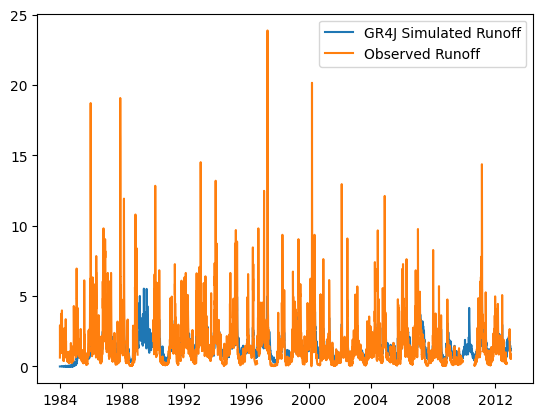

In [123]:
result_gr4j = _pyrun_GR4J(x_cali_gr4j, default_params_gr4j)
result_series_gr4j = pd.Series(result_gr4j, index=all_data.index)
plt.plot(result_series_gr4j, label="GR4J Simulated Runoff")
plt.plot(all_data['Qmm'], label="Observed Runoff")
print("GR4J NSE:", nash_sutcliffe_efficiency(all_data['Qmm'].values, result_gr4j))
print("GR4J Relative Error:", relative_error(all_data['Qmm'].values, result_gr4j))
plt.legend()

Calibrated GR4J NSE: 0.7825977494039699
Calibrated GR4J Relative Error: 8.76572220374738e-10


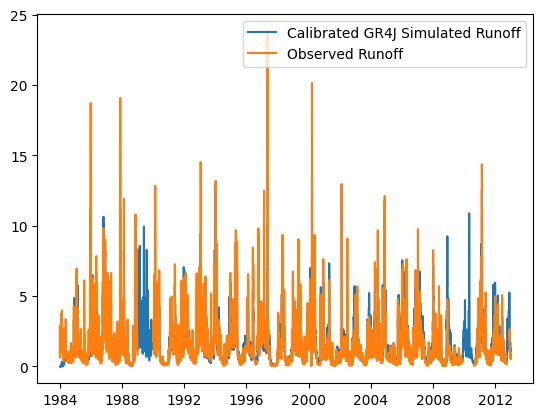

In [124]:
n_params_gr4j = len(default_params_gr4j)
fn_hm = _pyrun_GR4J
bestx_gr4j, calibration_result_gr4j = sceua(bounds_gr4j, max_iter, n_complex, n_params_gr4j, x_cali_gr4j, y_cali, fn_hm, cost_function)
result_calibrated_gr4j = _pyrun_GR4J(x_cali_gr4j, bestx_gr4j)
result_calibrated_series_gr4j = pd.Series(result_calibrated_gr4j, index=all_data.index)
plt.plot(result_calibrated_series_gr4j, label="Calibrated GR4J Simulated Runoff")
plt.plot(all_data['Qmm'], label="Observed Runoff")
print("Calibrated GR4J NSE:", nash_sutcliffe_efficiency(all_data['Qmm'].values, result_calibrated_gr4j))
print("Calibrated GR4J Relative Error:", relative_error(all_data['Qmm'].values, result_calibrated_gr4j))
plt.legend()